# 03: Model Selection

**Objective:** Compare a majority-class baseline, Logistic Regression, XGBoost, and Random Forest on the spirometry-derived COPD label (`copd_label = min(FEV1/FVC) < 0.70`). This is the **referral / case-finding model**: features contain no spirometry data, mirroring the use case of identifying unscreened patients who should be referred for spirometry. Select the best model based on AUC and sensitivity, then run a blood-group sensitivity analysis.

**Inputs:** `data/processed/features_referral.csv`, `data/processed/labels.csv`  
**Output:** `models/copd_model_v2.pkl` (best model, calibrated, threshold-optimised)

---

### Sections
1. Setup & data loading
2. Feature lists
3. Nested cross-validation (Baseline vs LR vs XGBoost vs RF)
4. Model comparison
5. Best model: calibration + threshold optimisation
6. SHAP analysis
7. Blood-group sensitivity analysis
8. Save artifact


## 1. Setup & data loading

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import joblib
import json
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix,
                              brier_score_loss, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

# Paths (relative to notebook location)
DATA_DIR   = Path('..') / 'data' / 'processed'
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')


Libraries loaded.


In [30]:
from sklearn.model_selection import train_test_split

# Load referral feature matrix (no spirometry features) and labels.
# This is the case-finding / Stage-1 model: predicts which unscreened patients
# should be referred for spirometry, using only demographics, habits, labs,
# comorbidities, and NLP signals.
X_df = pd.read_csv(DATA_DIR / 'features_referral.csv')
y_df = pd.read_csv(DATA_DIR / 'labels.csv')

# Stratified 80/20 split.
# StandardScaler is fit on X_train only (inside the imblearn Pipeline below).
train_idx, test_idx = train_test_split(
    X_df.index,
    test_size=0.20,
    stratify=y_df['copd_label'],
    random_state=42
)

X_train_df = X_df.loc[train_idx].reset_index(drop=True)
X_test_df  = X_df.loc[test_idx].reset_index(drop=True)
y_train_df = y_df.loc[train_idx].reset_index(drop=True)
y_test_df  = y_df.loc[test_idx].reset_index(drop=True)

print(f'Train: {X_train_df.shape[0]:,} rows x {X_train_df.shape[1]-1} features')
print(f'Test : {X_test_df.shape[0]:,} rows x {X_test_df.shape[1]-1} features')
print()
copd_tr = y_train_df['copd_label'].mean() * 100
copd_te = y_test_df['copd_label'].mean() * 100
print(f'Train COPD+ : {y_train_df["copd_label"].sum():,}  ({copd_tr:.1f}%)')
print(f'Test  COPD+ : {y_test_df["copd_label"].sum():,}  ({copd_te:.1f}%)')


Train: 7,958 rows x 33 features
Test : 1,990 rows x 33 features

Train COPD+ : 6,080  (76.4%)
Test  COPD+ : 1,520  (76.4%)


## 2. Feature lists

In [31]:
ALL_FEATURE_COLS = [c for c in X_train_df.columns if c != 'id_paciente']

# Main model: 30 features - excludes blood group dummies (no spirometry in referral set)
FEATURES_MAIN        = [c for c in ALL_FEATURE_COLS if not c.startswith('bg_')]

# Sensitivity model: 33 features - includes bg_A, bg_B, bg_AB
FEATURES_SENSITIVITY = ALL_FEATURE_COLS

# Arrays
X_train = X_train_df[FEATURES_MAIN].values
y_train = y_train_df['copd_label'].values

X_test  = X_test_df[FEATURES_MAIN].values
y_test  = y_test_df['copd_label'].values

print(f'FEATURES_MAIN:        {len(FEATURES_MAIN)} features (no spirometry, no blood group)')
print(f'FEATURES_SENSITIVITY: {len(FEATURES_SENSITIVITY)} features (adds bg_A, bg_B, bg_AB)')
bg_cols = [c for c in ALL_FEATURE_COLS if c.startswith('bg_')]
print(f'Blood group features: {bg_cols}')


FEATURES_MAIN:        30 features (no spirometry, no blood group)
FEATURES_SENSITIVITY: 33 features (adds bg_A, bg_B, bg_AB)
Blood group features: ['bg_A', 'bg_B', 'bg_AB']


## 3. Nested cross-validation

**Design:**
- Outer loop: 5-fold stratified CV (unbiased estimate of generalisation)
- Inner loop: 3-fold stratified CV (hyperparameter selection)
- SMOTE applied inside the inner loop only (no leakage into test folds)
- All CV runs on the **training set only**; the test set is locked until Section 6

Using `FEATURES_MAIN` (30 features) for the main comparison.

In [32]:
# CV runs on training set only
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Model definitions with hyperparameter grids
# Baseline: majority-class dummy. AUC = 0.5 by definition; sets the floor that
# all other models must beat meaningfully (76.4% COPD+ prevalence makes accuracy
# a misleading metric without this reference point).
# Pipeline order for Logistic Regression: imputer -> scaler -> smote -> clf
#   Imputer runs first so SMOTE receives no NaN values.
#   Scaler precedes SMOTE so k-NN synthetic neighbours are computed in
#   standardised feature space (distance-sensitive).
# Pipeline order for tree models: imputer -> smote -> clf
#   No scaler needed (trees are scale-invariant).
models = {
    'Baseline (majority)': {
        'pipeline': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf',     DummyClassifier(strategy='most_frequent'))
        ]),
        'param_grid': {}
    },
    'Logistic Regression': {
        'pipeline': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
            ('smote',   SMOTE(random_state=42)),
            ('clf',     LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'param_grid': {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l1', 'l2'],
            'clf__solver': ['liblinear']
        }
    },
    'XGBoost': {
        'pipeline': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('smote',   SMOTE(random_state=42)),
            ('clf',     XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0))
        ]),
        'param_grid': {
            'clf__n_estimators':  [100, 300],
            'clf__max_depth':     [3, 5],
            'clf__learning_rate': [0.05, 0.1],
            'clf__subsample':     [0.8, 1.0]
        }
    },
    'Random Forest': {
        'pipeline': ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('smote',   SMOTE(random_state=42)),
            ('clf',     RandomForestClassifier(random_state=42))
        ]),
        'param_grid': {
            'clf__n_estimators': [100, 300],
            'clf__max_depth':    [None, 10, 20],
            'clf__min_samples_leaf': [1, 5]
        }
    }
}

print('Model definitions ready.')


Model definitions ready.


In [33]:
# -- Nested CV loop -----------------------------------------------------------
results = {}

for model_name, config in models.items():
    print(f'\n--- {model_name} ---')
    outer_aucs   = []
    outer_aps    = []
    best_params_list = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_tr, X_te = X_train[train_idx], X_train[test_idx]
        y_tr, y_te = y_train[train_idx], y_train[test_idx]

        # Inner CV: hyperparameter search
        search = GridSearchCV(
            config['pipeline'],
            config['param_grid'],
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1,
            refit=True
        )
        search.fit(X_tr, y_tr)

        # Evaluate on outer test fold
        y_prob = search.predict_proba(X_te)[:, 1]
        auc    = roc_auc_score(y_te, y_prob)
        ap     = average_precision_score(y_te, y_prob)

        outer_aucs.append(auc)
        outer_aps.append(ap)
        best_params_list.append(search.best_params_)

        print(f'  Fold {fold_idx+1}: AUC={auc:.4f}  AP={ap:.4f}  best_params={search.best_params_}')

    results[model_name] = {
        'aucs': outer_aucs,
        'aps':  outer_aps,
        'mean_auc': np.mean(outer_aucs),
        'std_auc':  np.std(outer_aucs),
        'mean_ap':  np.mean(outer_aps),
        'best_params_list': best_params_list
    }
    print(f'  -> Mean AUC: {np.mean(outer_aucs):.4f} +- {np.std(outer_aucs):.4f}')


--- Baseline (majority) ---
  Fold 1: AUC=0.5000  AP=0.7638  best_params={}
  Fold 2: AUC=0.5000  AP=0.7638  best_params={}
  Fold 3: AUC=0.5000  AP=0.7638  best_params={}
  Fold 4: AUC=0.5000  AP=0.7643  best_params={}
  Fold 5: AUC=0.5000  AP=0.7643  best_params={}
  -> Mean AUC: 0.5000 +- 0.0000

--- Logistic Regression ---
  Fold 1: AUC=0.6308  AP=0.8440  best_params={'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
  Fold 2: AUC=0.6263  AP=0.8406  best_params={'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
  Fold 3: AUC=0.6094  AP=0.8270  best_params={'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
  Fold 4: AUC=0.6001  AP=0.8271  best_params={'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
  Fold 5: AUC=0.6224  AP=0.8270  best_params={'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
  -> Mean AUC: 0.6178 +- 0.0114

--- XGBoost ---
  Fold 1: AUC=0.6056  AP=0.8328  best_params={'clf__learning_

## 4. Model comparison

In [34]:
# Summary table
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Mean AUC': [results[m]['mean_auc'] for m in results],
    'Std AUC':  [results[m]['std_auc']  for m in results],
    'Mean AP':  [results[m]['mean_ap']  for m in results],
}).sort_values('Mean AUC', ascending=False).reset_index(drop=True)

comparison['Mean AUC'] = comparison['Mean AUC'].map('{:.4f}'.format)
comparison['Std AUC']  = comparison['Std AUC'].map('{:.4f}'.format)
comparison['Mean AP']  = comparison['Mean AP'].map('{:.4f}'.format)

print('Nested CV Results (FEATURES_MAIN, 36 features):')
print(comparison.to_string(index=False))

Nested CV Results (FEATURES_MAIN, 36 features):
              Model Mean AUC Std AUC Mean AP
Logistic Regression   0.6178  0.0114  0.8331
            XGBoost   0.6075  0.0086  0.8299
      Random Forest   0.5913  0.0105  0.8210
Baseline (majority)   0.5000  0.0000  0.7640


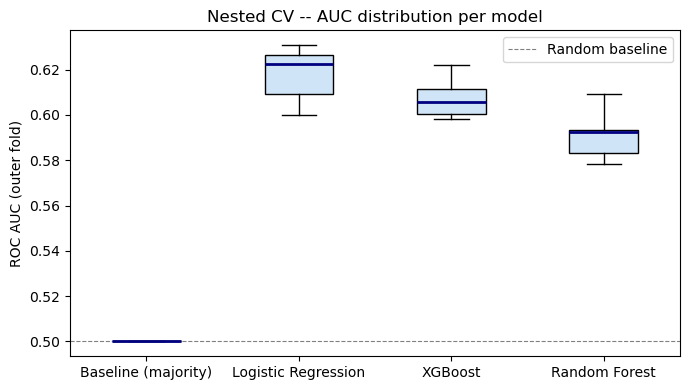

In [35]:
# AUC boxplot
fig, ax = plt.subplots(figsize=(7, 4))
data_to_plot = [results[m]['aucs'] for m in results]
ax.boxplot(data_to_plot, labels=list(results.keys()), patch_artist=True,
           boxprops=dict(facecolor='#d0e4f7'), medianprops=dict(color='navy', linewidth=2))
ax.set_ylabel('ROC AUC (outer fold)')
ax.set_title('Nested CV -- AUC distribution per model')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Best model: refit on train, calibrate, optimise threshold

Refit the winning model on the full **training set** using its most frequently selected hyperparameters. Apply Platt scaling calibration. Optimise threshold for >=90% sensitivity using training CV probabilities.

In [36]:
# Select best model by mean AUC
best_model_name = max(results, key=lambda m: results[m]['mean_auc'])
print(f'Best model: {best_model_name}')

# Most common best params across outer folds
from collections import Counter
param_strings = [json.dumps(p, sort_keys=True) for p in results[best_model_name]['best_params_list']]
best_params = json.loads(Counter(param_strings).most_common(1)[0][0])
print(f'Best hyperparameters: {best_params}')

Best model: Logistic Regression
Best hyperparameters: {'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}


In [37]:
# Refit on full dataset with best params
final_pipeline = models[best_model_name]['pipeline']
final_pipeline.set_params(**best_params)
final_pipeline.fit(X_train, y_train)

# Calibrate with Platt scaling using cross-validation
# Note: refit on calibration data (use base estimator post-SMOTE)
# We calibrate the fitted pipeline using isotonic/sigmoid on held-out data
calibrated_model = CalibratedClassifierCV(final_pipeline, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

print('Final model fitted and calibrated.')

Final model fitted and calibrated.


In [38]:
# Threshold optimisation: use cross-val probabilities on TRAINING set
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, precision_score, f1_score

y_prob_train_cv = cross_val_predict(
    calibrated_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

fpr_tr, tpr_tr, thresholds_tr = roc_curve(y_train, y_prob_train_cv)
candidate_idxs = np.where(tpr_tr >= 0.90)[0]
if len(candidate_idxs) > 0:
    opt_idx = candidate_idxs[np.argmax(thresholds_tr[candidate_idxs])]
    OPTIMAL_THRESHOLD = thresholds_tr[opt_idx]
else:
    OPTIMAL_THRESHOLD = 0.5

y_pred_train = (y_prob_train_cv >= OPTIMAL_THRESHOLD).astype(int)
train_auc  = roc_auc_score(y_train, y_prob_train_cv)
train_sens = recall_score(y_train, y_pred_train)
train_spec = recall_score(y_train, y_pred_train, pos_label=0)
train_prec = precision_score(y_train, y_pred_train)
train_f1   = f1_score(y_train, y_pred_train)
train_brier= brier_score_loss(y_train, y_prob_train_cv)

print(f'Optimal threshold (from training CV): {OPTIMAL_THRESHOLD:.4f}')
print(f'Training CV metrics:')
print(f'  AUC         : {train_auc:.4f}')
print(f'  Brier score : {train_brier:.4f}')
print(f'  Sensitivity : {train_sens:.3f}')
print(f'  Specificity : {train_spec:.3f}')
print(f'  Precision   : {train_prec:.3f}')
print(f'  F1          : {train_f1:.3f}')


Optimal threshold (from training CV): 0.6671
Training CV metrics:
  AUC         : 0.6172
  Brier score : 0.1749
  Sensitivity : 0.900
  Specificity : 0.178
  Precision   : 0.780
  F1          : 0.836


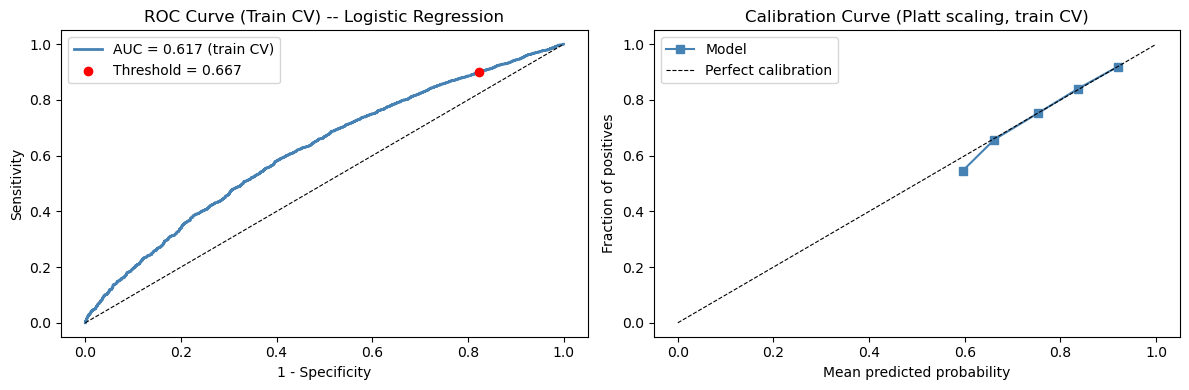

In [39]:
# ROC and calibration plots (training CV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr_tr, tpr_tr, color='steelblue', lw=2,
             label=f'AUC = {train_auc:.3f} (train CV)')
axes[0].plot([0,1],[0,1], 'k--', lw=0.8)
axes[0].scatter(fpr_tr[opt_idx], tpr_tr[opt_idx], color='red', zorder=5,
                label=f'Threshold = {OPTIMAL_THRESHOLD:.3f}')
axes[0].set_xlabel('1 - Specificity'); axes[0].set_ylabel('Sensitivity')
axes[0].set_title(f'ROC Curve (Train CV) -- {best_model_name}')
axes[0].legend()

prob_true, prob_pred_cal = calibration_curve(y_train, y_prob_train_cv, n_bins=10)
axes[1].plot(prob_pred_cal, prob_true, 's-', color='steelblue', label='Model')
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve (Platt scaling, train CV)')
axes[1].legend()

plt.tight_layout()
plt.show()


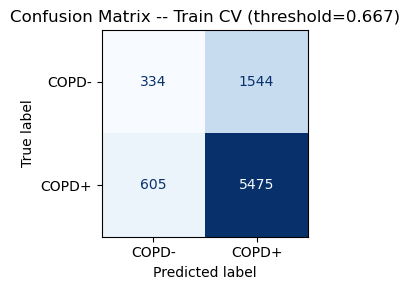

Training CV classification report:
              precision    recall  f1-score   support

       COPD-       0.36      0.18      0.24      1878
       COPD+       0.78      0.90      0.84      6080

    accuracy                           0.73      7958
   macro avg       0.57      0.54      0.54      7958
weighted avg       0.68      0.73      0.69      7958



In [40]:
# Confusion matrix on training CV predictions
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=['COPD-', 'COPD+'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix -- Train CV (threshold={OPTIMAL_THRESHOLD:.3f})')
plt.tight_layout()
plt.show()
print('Training CV classification report:')
from sklearn.metrics import classification_report
print(classification_report(y_train, y_pred_train, target_names=['COPD-', 'COPD+']))


## 6. Hold-out test set evaluation

Apply the calibrated model and optimised threshold to the **locked test set** (20%, never seen during training or model selection). This gives the final unbiased performance estimate.

Comparison of training and test metrics to check for overfitting.

In [41]:
# -- Apply to test set ----------------------------------------------------
y_prob_test = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)

test_auc   = roc_auc_score(y_test, y_prob_test)
test_sens  = recall_score(y_test, y_pred_test)
test_spec  = recall_score(y_test, y_pred_test, pos_label=0)
test_prec  = precision_score(y_test, y_pred_test)
test_f1    = f1_score(y_test, y_pred_test)
test_brier = brier_score_loss(y_test, y_prob_test)

# -- Train vs Test comparison table (Overfitting_test pattern) ------------
from sklearn.metrics import accuracy_score

metrics_comparison = pd.DataFrame({
    'Metric': ['ROC AUC', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'Brier'],
    'Train CV': [train_auc, train_sens, train_spec, train_prec, train_f1, train_brier],
    'Test':     [test_auc,  test_sens,  test_spec,  test_prec,  test_f1,  test_brier],
}).set_index('Metric')
metrics_comparison['Delta'] = (
    metrics_comparison['Test'] - metrics_comparison['Train CV']
)

print(f'Best model: {best_model_name}  |  Threshold: {OPTIMAL_THRESHOLD:.4f}')
print()
print(metrics_comparison.map(lambda x: f'{x:.4f}').to_string())

# Flag potential overfitting
auc_drop = train_auc - test_auc
if auc_drop > 0.05:
    print(f'\nWARNING: AUC drop of {auc_drop:.3f} suggests overfitting.')
else:
    print(f'\nOverfitting check: AUC drop = {auc_drop:.3f} (acceptable)')


Best model: Logistic Regression  |  Threshold: 0.6671

            Train CV    Test    Delta
Metric                               
ROC AUC       0.6172  0.5861  -0.0311
Sensitivity   0.9005  0.8888  -0.0117
Specificity   0.1778  0.1745  -0.0034
Precision     0.7800  0.7769  -0.0031
F1            0.8359  0.8291  -0.0069
Brier         0.1749  0.1777   0.0028

Overfitting check: AUC drop = 0.031 (acceptable)


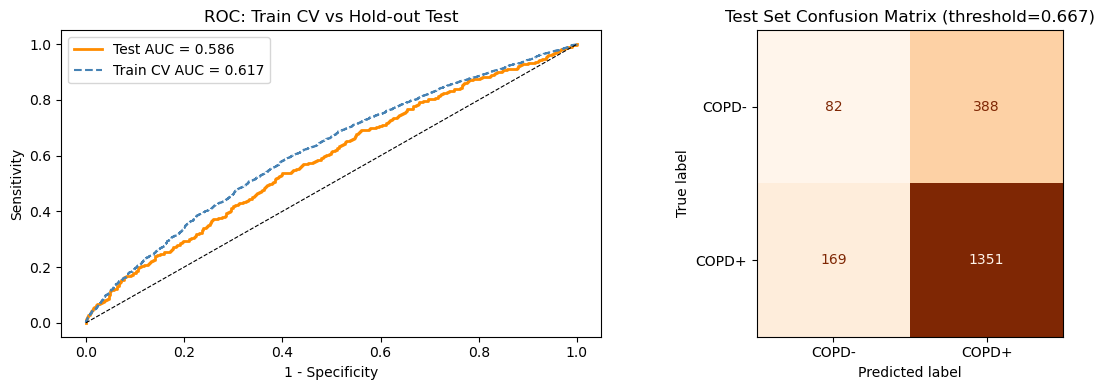

Hold-out test set classification report:
              precision    recall  f1-score   support

       COPD-       0.33      0.17      0.23       470
       COPD+       0.78      0.89      0.83      1520

    accuracy                           0.72      1990
   macro avg       0.55      0.53      0.53      1990
weighted avg       0.67      0.72      0.69      1990



In [42]:
# -- Test set ROC curve ---------------------------------------------------
fpr_te, tpr_te, _ = roc_curve(y_test, y_prob_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC
axes[0].plot(fpr_te, tpr_te, color='darkorange', lw=2,
             label=f'Test AUC = {test_auc:.3f}')
axes[0].plot(fpr_tr, tpr_tr, color='steelblue', lw=1.5, linestyle='--',
             label=f'Train CV AUC = {train_auc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=0.8)
axes[0].set_xlabel('1 - Specificity'); axes[0].set_ylabel('Sensitivity')
axes[0].set_title('ROC: Train CV vs Hold-out Test')
axes[0].legend()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['COPD-', 'COPD+'],
    cmap='Oranges', ax=axes[1], colorbar=False
)
axes[1].set_title(f'Test Set Confusion Matrix (threshold={OPTIMAL_THRESHOLD:.3f})')

plt.tight_layout()
plt.show()

print('Hold-out test set classification report:')
print(classification_report(y_test, y_pred_test, target_names=['COPD-', 'COPD+']))


## 7. SHAP analysis

SHAP explains individual predictions. For LR we use `LinearExplainer`; for tree models `TreeExplainer`.

In [43]:
# Extract the base estimator (last step) from the best-fit pipeline
# SHAP needs a plain model (no pipeline wrapper) fit on clean, resampled data.
# Impute first (median) so SMOTE and SHAP receive no NaN values.
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_imp, y_train)

feature_names = FEATURES_MAIN

if best_model_name == 'Logistic Regression':
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_res)
    shap_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_params = {k.replace('clf__',''):v for k,v in best_params.items() if k.startswith('clf__')}
    shap_model.set_params(**lr_params)
    shap_model.fit(X_scaled, y_res)
    explainer = shap.LinearExplainer(shap_model, X_scaled)
    shap_values = explainer.shap_values(X_scaled[:500])
    X_display = pd.DataFrame(X_scaled[:500], columns=feature_names)

elif best_model_name == 'XGBoost':
    shap_model = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
    xgb_params = {k.replace('clf__',''):v for k,v in best_params.items() if k.startswith('clf__')}
    shap_model.set_params(**xgb_params)
    shap_model.fit(X_res, y_res)
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_res[:500])
    X_display = pd.DataFrame(X_res[:500], columns=feature_names)

else:  # Random Forest
    shap_model = RandomForestClassifier(random_state=42)
    rf_params = {k.replace('clf__',''):v for k,v in best_params.items() if k.startswith('clf__')}
    shap_model.set_params(**rf_params)
    shap_model.fit(X_res, y_res)
    explainer = shap.TreeExplainer(shap_model)
    shap_values_raw = explainer.shap_values(X_res[:500])
    # RF returns list [class0, class1] -- take class 1
    shap_values = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw
    X_display = pd.DataFrame(X_res[:500], columns=feature_names)

print(f'SHAP values computed for {best_model_name}. Shape: {np.array(shap_values).shape}')


SHAP values computed for Logistic Regression. Shape: (500, 30)


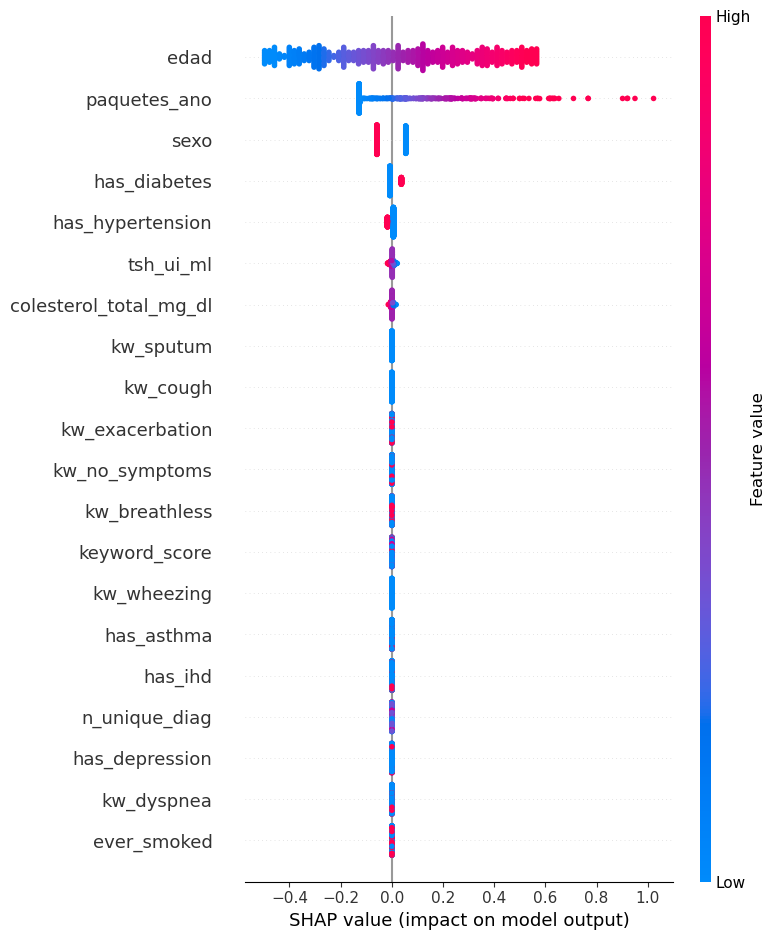

In [44]:
# SHAP summary plot -- beeswarm
shap.summary_plot(shap_values, X_display, plot_type='dot', max_display=20, show=True)

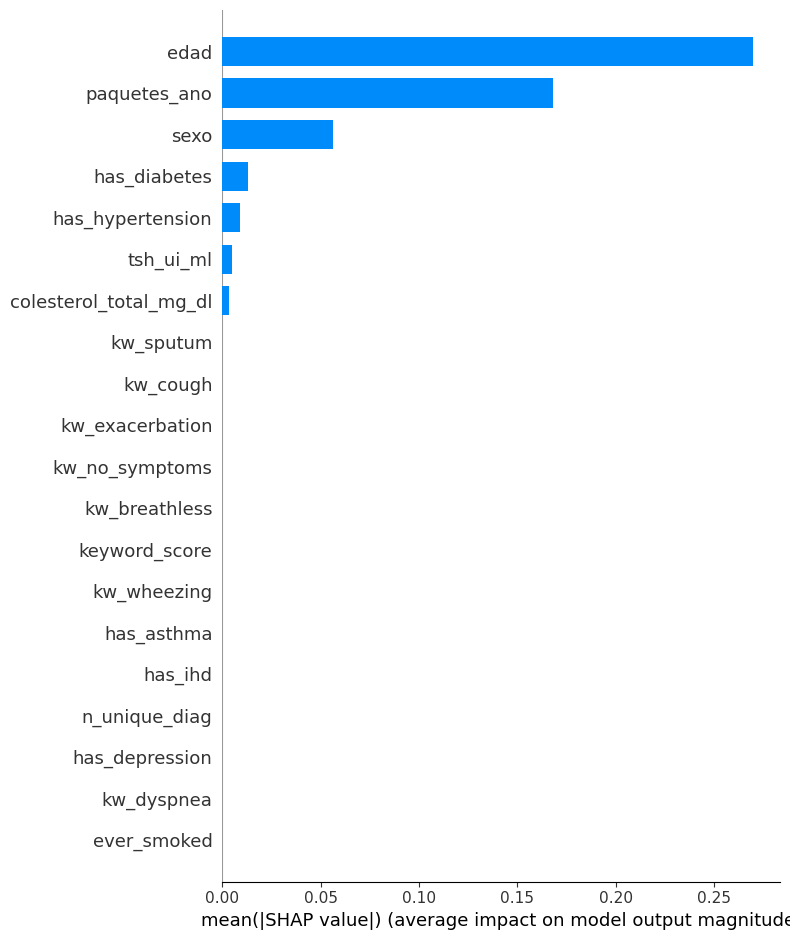

In [45]:
# SHAP bar plot -- mean absolute importance
shap.summary_plot(shap_values, X_display, plot_type='bar', max_display=20, show=True)

In [46]:
# Top 10 features by mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_shap})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
print('Top 10 features by mean |SHAP|:')
print(shap_df.head(10).to_string(index=False))

Top 10 features by mean |SHAP|:
               feature  mean_abs_shap
                  edad       0.269954
          paquetes_ano       0.168301
                  sexo       0.056491
          has_diabetes       0.013125
      has_hypertension       0.008798
             tsh_ui_ml       0.004888
colesterol_total_mg_dl       0.003381
        fumador_actual       0.000000
             exfumador       0.000000
      actividad_fisica       0.000000


## 8. Blood-group sensitivity analysis

Train the same best model on `FEATURES_SENSITIVITY` (39 features, includes `bg_A`, `bg_B`, `bg_AB`). Compare AUC delta and SHAP weight of blood group features.

In [47]:
X_sens_train = X_train_df[FEATURES_SENSITIVITY].values
X_sens_test  = X_test_df[FEATURES_SENSITIVITY].values

# Nested CV on sensitivity feature set (train only -- same best model)
sens_pipeline = models[best_model_name]['pipeline']
sens_pipeline.set_params(**best_params)

sens_aucs = []
for train_idx, test_idx in outer_cv.split(X_sens_train, y_train):
    X_tr, X_te = X_sens_train[train_idx], X_sens_train[test_idx]
    y_tr, y_te = y_train[train_idx], y_train[test_idx]
    sens_pipeline.fit(X_tr, y_tr)
    y_prob = sens_pipeline.predict_proba(X_te)[:, 1]
    sens_aucs.append(roc_auc_score(y_te, y_prob))

main_mean_auc = results[best_model_name]['mean_auc']
sens_mean_auc = np.mean(sens_aucs)
delta_auc     = sens_mean_auc - main_mean_auc

print(f'Main model AUC  (36 features, train CV): {main_mean_auc:.4f}')
print(f'Sensitivity AUC (39 features, train CV): {sens_mean_auc:.4f}')
print(f'Delta AUC:                               {delta_auc:+.4f}')
print()
if abs(delta_auc) < 0.005:
    print('Interpretation: Blood group adds NO meaningful signal (|deltaAUC| < 0.005).')
elif delta_auc > 0.005:
    print('Interpretation: Blood group adds marginal signal. Investigate SHAP before including.')
else:
    print('Interpretation: Blood group slightly HURTS performance. Exclude from final model.')


Main model AUC  (36 features, train CV): 0.6178
Sensitivity AUC (39 features, train CV): 0.6183
Delta AUC:                               +0.0005

Interpretation: Blood group adds NO meaningful signal (|deltaAUC| < 0.005).


In [48]:
# SHAP weights for bg_* features in sensitivity model
imputer_s = SimpleImputer(strategy='median')
X_sens_train_imp = imputer_s.fit_transform(X_sens_train)

if best_model_name == 'XGBoost':
    X_res_s, y_res_s = smote.fit_resample(X_sens_train_imp, y_train)
    shap_model_s = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
    xgb_params_s = {k.replace('clf__',''):v for k,v in best_params.items() if k.startswith('clf__')}
    shap_model_s.set_params(**xgb_params_s)
    shap_model_s.fit(X_res_s, y_res_s)
    explainer_s = shap.TreeExplainer(shap_model_s)
    shap_values_s = explainer_s.shap_values(X_res_s[:500])
elif best_model_name == 'Random Forest':
    X_res_s, y_res_s = smote.fit_resample(X_sens_train_imp, y_train)
    shap_model_s = RandomForestClassifier(random_state=42)
    rf_params_s = {k.replace('clf__',''):v for k,v in best_params.items() if k.startswith('clf__')}
    shap_model_s.set_params(**rf_params_s)
    shap_model_s.fit(X_res_s, y_res_s)
    explainer_s = shap.TreeExplainer(shap_model_s)
    shap_raw_s = explainer_s.shap_values(X_res_s[:500])
    shap_values_s = shap_raw_s[1] if isinstance(shap_raw_s, list) else shap_raw_s
else:  # LR
    X_res_s, y_res_s = smote.fit_resample(X_sens_train_imp, y_train)
    scaler_s = StandardScaler()
    X_scaled_s = scaler_s.fit_transform(X_res_s)
    shap_model_s = LogisticRegression(max_iter=1000, random_state=42)
    lr_params_s = {k.replace('clf__',''):v for k,v in best_params.items() if k.startswith('clf__')}
    shap_model_s.set_params(**lr_params_s)
    shap_model_s.fit(X_scaled_s, y_res_s)
    explainer_s = shap.LinearExplainer(shap_model_s, X_scaled_s)
    shap_values_s = explainer_s.shap_values(X_scaled_s[:500])

# Report bg_* SHAP weights
mean_shap_s = np.abs(shap_values_s).mean(axis=0)
shap_df_s = pd.DataFrame({'feature': FEATURES_SENSITIVITY, 'mean_abs_shap': mean_shap_s})
bg_shap = shap_df_s[shap_df_s['feature'].str.startswith('bg_')].sort_values('mean_abs_shap', ascending=False)

print('Blood group feature SHAP weights (sensitivity model):')
print(bg_shap.to_string(index=False))
print()
total_shap = mean_shap_s.sum()
bg_total_shap = bg_shap['mean_abs_shap'].sum()
print(f'Blood group features account for {bg_total_shap/total_shap*100:.2f}% of total SHAP magnitude')


Blood group feature SHAP weights (sensitivity model):
feature  mean_abs_shap
   bg_A            0.0
   bg_B            0.0
  bg_AB            0.0

Blood group features account for 0.00% of total SHAP magnitude


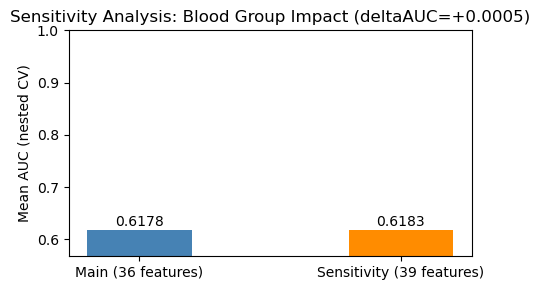

In [49]:
# AUC delta bar chart
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(['Main (36 features)', 'Sensitivity (39 features)'],
              [main_mean_auc, sens_mean_auc],
              color=['steelblue', 'darkorange'], width=0.4)
ax.set_ylim(max(0, min(main_mean_auc, sens_mean_auc) - 0.05), 1.0)
ax.set_ylabel('Mean AUC (nested CV)')
ax.set_title(f'Sensitivity Analysis: Blood Group Impact (deltaAUC={delta_auc:+.4f})')
for bar, val in zip(bars, [main_mean_auc, sens_mean_auc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Save model artifact

In [50]:
# Save calibrated model and metadata
artifact = {
    'model': calibrated_model,
    'threshold': OPTIMAL_THRESHOLD,
    'feature_names': FEATURES_MAIN,
    'model_name': best_model_name,
    'metrics': {
        'auc_train_cv':  round(train_auc, 4),
        'auc_test':      round(test_auc, 4),
        'sensitivity_test': round(float(test_sens), 4),
        'specificity_test': round(float(test_spec), 4),
        'brier_test':    round(test_brier, 4),
        'delta_auc_blood_group': round(float(delta_auc), 4)
    }
}

out_path = MODELS_DIR / 'copd_model_v2.pkl'
joblib.dump(artifact, out_path)
print(f'Artifact saved: {out_path}')
print(f'  Model       : {best_model_name}')
print(f'  Threshold   : {OPTIMAL_THRESHOLD:.4f}')
print(f'  Features    : {len(FEATURES_MAIN)}')
print(f'  AUC (train CV): {train_auc:.4f}')
print(f'  AUC (test)    : {test_auc:.4f}')
print(f'  Sensitivity (test): {test_sens:.3f}')
print(f'  Specificity (test): {test_spec:.3f}')


Artifact saved: ..\models\copd_model_v2.pkl
  Model       : Logistic Regression
  Threshold   : 0.6671
  Features    : 30
  AUC (train CV): 0.6172
  AUC (test)    : 0.5861
  Sensitivity (test): 0.889
  Specificity (test): 0.174


---
## Summary

| Step | Detail |
|---|---|
| Nested CV (5-fold outer, 3-fold inner) | LR vs XGBoost vs RF on 30 features (train only) |
| Best model | See Section 5 output |
| Calibration | Platt scaling (sigmoid, 5-fold CV on train) |
| Threshold | Optimised on train CV for >=90% sensitivity |
| Hold-out evaluation | Locked test set (20%), evaluated in Section 6 |
| Blood group sensitivity analysis | deltaAUC train CV reported in Section 8 |
| Artifact | `models/copd_model_v2.pkl` with test metrics |

**Next step:** Update `Model_iteration_report.md` 2.7 with test metrics, then integrate `copd_model_v2.pkl` into the Streamlit app.